## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_EL = 'αττικης'

In [4]:
YEAR = 2023
MONTH = 'July'
PERIOD = '2nd'

In [5]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_{YEAR}-{MONTH}-{PERIOD}_filled.csv', encoding=enc)


In [6]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_lat,lst_lon,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2023-07-16,2023,7,2023-07-14,37.991999,23.654887,0.077811,-0.060675,-0.147671,0.060675,0.105506,-0.058762,-0.166547,0.058762,0.031436,0.011369,0.025064,0.011369,2023-07-07,37.991999,23.654887,15874.0,15066.0,37.991999,23.654887,14383.000000,14058.500000,14342.555556,13972.380952,14651.923077,14207.846154,14829.846154,14265.500000,2023-07-15,37.950174,23.650108,348.910701,2023-07-09,2023-07-02,2023-07-09,2023-07-02,0.0,0.0
1,αγιας παρασκευης,αττικης,23.82642,38.00806,2023-07-16,2023,7,2023-07-14,38.009965,23.825567,0.196562,0.022214,-0.226010,-0.022214,0.199080,0.025059,-0.225148,-0.025059,0.021939,0.014275,0.015714,0.014275,2023-07-07,38.009965,23.825567,15683.0,15051.0,38.009965,23.825567,14333.928571,14047.200000,14411.600000,13959.363636,14596.000000,14136.000000,14752.555556,14223.200000,2023-07-15,38.050174,23.850109,425.951674,2023-07-09,2023-07-02,2023-07-09,2023-07-02,0.0,0.0
2,αγιου δημητριου,αττικης,23.73031,37.93357,2023-07-16,2023,7,2023-07-14,37.933609,23.731244,0.125097,-0.027045,-0.184700,0.027045,0.106977,-0.030677,-0.166602,0.030677,0.020927,0.008113,0.017353,0.008113,2023-07-07,37.933609,23.731244,15812.0,15099.0,37.933609,23.731244,14390.461538,14124.550000,14357.363636,13996.130435,14688.400000,14187.062500,14885.647059,14302.500000,2023-07-15,37.950174,23.750109,365.646401,2023-07-09,2023-07-02,2023-07-09,2023-07-02,0.0,0.0
3,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2023-07-16,2023,7,2023-07-14,38.045898,23.713278,0.149989,-0.058022,-0.201784,0.058022,0.171748,-0.060975,-0.219257,0.060975,0.032874,0.014621,0.021298,0.014621,2023-07-07,38.045898,23.713278,15827.0,15049.0,38.045898,23.713278,14369.750000,14037.578947,14313.300000,13963.473684,14693.000000,14156.333333,14841.250000,14223.666667,2023-07-15,38.050174,23.750109,437.278102,2023-07-09,2023-07-02,2023-07-09,2023-07-02,0.0,0.0
4,αγκιστριου,αττικης,23.34009,37.69503,2023-07-16,2023,7,2023-07-14,37.695555,23.340477,0.283677,-0.045093,-0.226344,0.045093,0.294952,-0.031979,-0.238844,0.031979,0.023628,0.048797,0.012318,0.048797,2023-07-07,37.695555,23.340477,15456.0,14995.0,37.695555,23.340477,14368.608696,14189.722222,14305.315789,14124.388889,14433.318182,14238.400000,14545.680000,14261.666667,2023-07-15,37.650172,23.350107,485.607311,2023-07-09,2023-07-02,2023-07-09,2023-07-02,0.0,0.0


In [7]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [8]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [9]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [10]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2023-07-16,2023,7,0.077811,-0.060675,-0.147671,0.060675,0.105506,-0.058762,-0.166547,0.058762,0.031436,0.011369,0.025064,0.011369,15874.0,15066.0,14383.000000,14058.500000,14342.555556,13972.380952,14651.923077,14207.846154,14829.846154,14265.500000,348.910701,0.0,0.0
1,αγιας παρασκευης,αττικης,23.82642,38.00806,2023-07-16,2023,7,0.196562,0.022214,-0.226010,-0.022214,0.199080,0.025059,-0.225148,-0.025059,0.021939,0.014275,0.015714,0.014275,15683.0,15051.0,14333.928571,14047.200000,14411.600000,13959.363636,14596.000000,14136.000000,14752.555556,14223.200000,425.951674,0.0,0.0
2,αγιου δημητριου,αττικης,23.73031,37.93357,2023-07-16,2023,7,0.125097,-0.027045,-0.184700,0.027045,0.106977,-0.030677,-0.166602,0.030677,0.020927,0.008113,0.017353,0.008113,15812.0,15099.0,14390.461538,14124.550000,14357.363636,13996.130435,14688.400000,14187.062500,14885.647059,14302.500000,365.646401,0.0,0.0
3,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2023-07-16,2023,7,0.149989,-0.058022,-0.201784,0.058022,0.171748,-0.060975,-0.219257,0.060975,0.032874,0.014621,0.021298,0.014621,15827.0,15049.0,14369.750000,14037.578947,14313.300000,13963.473684,14693.000000,14156.333333,14841.250000,14223.666667,437.278102,0.0,0.0
4,αγκιστριου,αττικης,23.34009,37.69503,2023-07-16,2023,7,0.283677,-0.045093,-0.226344,0.045093,0.294952,-0.031979,-0.238844,0.031979,0.023628,0.048797,0.012318,0.048797,15456.0,14995.0,14368.608696,14189.722222,14305.315789,14124.388889,14433.318182,14238.400000,14545.680000,14261.666667,485.607311,0.0,0.0


In [11]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2023-07-16,αγιας βαρβαρας,αττικης,23.656970,37.992200,2023.0,7.0,0.077811,-0.060675,-0.147671,0.060675,0.105506,-0.058762,-0.166547,0.058762,0.031436,0.011369,0.025064,0.011369,15874.000000,15066.000000,14383.000000,14058.500000,14342.555556,13972.380952,14651.923077,14207.846154,14829.846154,14265.500000,348.910701,0.0,0.0
1,2023-07-16,αγιας παρασκευης,αττικης,23.826420,38.008060,2023.0,7.0,0.196562,0.022214,-0.226010,-0.022214,0.199080,0.025059,-0.225148,-0.025059,0.021939,0.014275,0.015714,0.014275,15683.000000,15051.000000,14333.928571,14047.200000,14411.600000,13959.363636,14596.000000,14136.000000,14752.555556,14223.200000,425.951674,0.0,0.0
2,2023-07-16,αγιου δημητριου,αττικης,23.730310,37.933570,2023.0,7.0,0.125097,-0.027045,-0.184700,0.027045,0.106977,-0.030677,-0.166602,0.030677,0.020927,0.008113,0.017353,0.008113,15812.000000,15099.000000,14390.461538,14124.550000,14357.363636,13996.130435,14688.400000,14187.062500,14885.647059,14302.500000,365.646401,0.0,0.0
3,2023-07-16,αγιων αναργυρων καματερου,αττικης,23.713410,38.047210,2023.0,7.0,0.149989,-0.058022,-0.201784,0.058022,0.171748,-0.060975,-0.219257,0.060975,0.032874,0.014621,0.021298,0.014621,15827.000000,15049.000000,14369.750000,14037.578947,14313.300000,13963.473684,14693.000000,14156.333333,14841.250000,14223.666667,437.278102,0.0,0.0
4,2023-07-16,αγκιστριου,αττικης,23.340090,37.695030,2023.0,7.0,0.283677,-0.045093,-0.226344,0.045093,0.294952,-0.031979,-0.238844,0.031979,0.023628,0.048797,0.012318,0.048797,15456.000000,14995.000000,14368.608696,14189.722222,14305.315789,14124.388889,14433.318182,14238.400000,14545.680000,14261.666667,485.607311,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,2023-07-16,φιλοθεης ψυχικου,αττικης,23.776280,38.014770,2023.0,7.0,0.261916,0.040467,-0.273637,-0.040467,0.240342,0.027923,-0.261228,-0.027923,0.025810,0.022008,0.019134,0.022008,15746.000000,15022.000000,14336.631579,14058.052632,14351.083333,13962.608696,14601.846154,14136.722222,14814.133333,14253.928571,437.278102,0.0,0.0
62,2023-07-16,φυλης,αττικης,23.688620,38.106703,2023.0,7.0,0.265969,-0.024227,-0.279033,0.024227,0.295066,-0.004797,-0.290480,0.004797,0.037955,0.037631,0.019783,0.037631,15616.666667,14862.666667,14286.856209,13919.959831,14262.083333,13867.802315,14500.012698,14007.878571,14697.305556,14082.353535,400.114421,0.0,0.0
63,2023-07-16,χαλανδριου,αττικης,23.809410,38.022260,2023.0,7.0,0.218797,0.033538,-0.246629,-0.033538,0.224506,0.032102,-0.249801,-0.032102,0.041628,0.030653,0.029128,0.030653,15699.000000,15071.000000,14348.000000,14057.578947,14377.500000,13986.142857,14647.666667,14128.588235,14793.333333,14171.142857,425.951674,0.0,0.0
64,2023-07-16,χαϊδαριου,αττικης,23.630840,38.009420,2023.0,7.0,0.274331,-0.066060,-0.260336,0.066060,0.273977,-0.043546,-0.257279,0.043546,0.023050,0.032023,0.011195,0.032023,15803.000000,14989.000000,14355.380952,14021.611111,14362.533333,13924.600000,14569.875000,14147.933333,14794.058824,14248.400000,439.846210,0.0,0.0


In [12]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [13]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [14]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [15]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [16]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [17]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'CENTRAL MACEDONIA'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [18]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [19]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

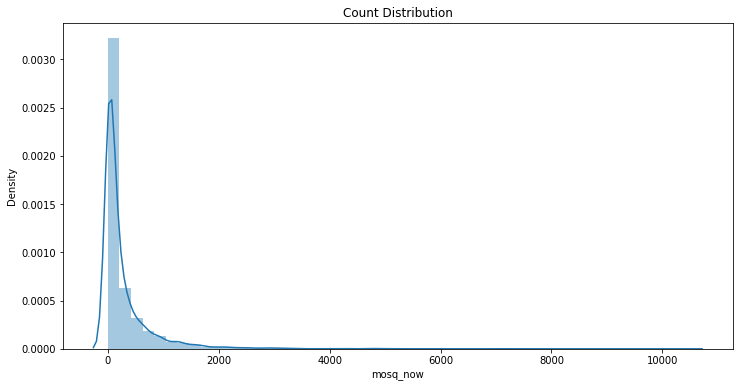

In [20]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [21]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

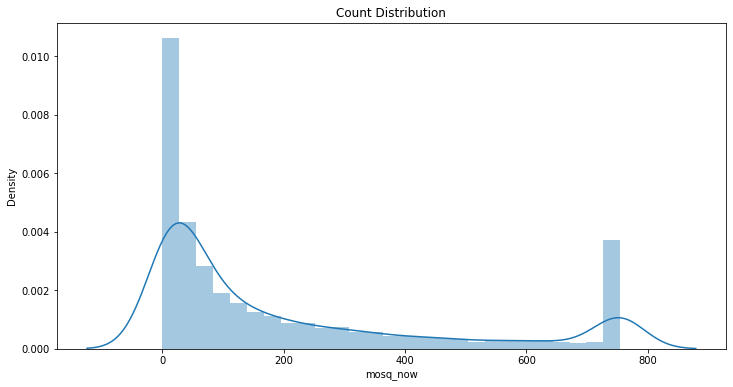

In [22]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

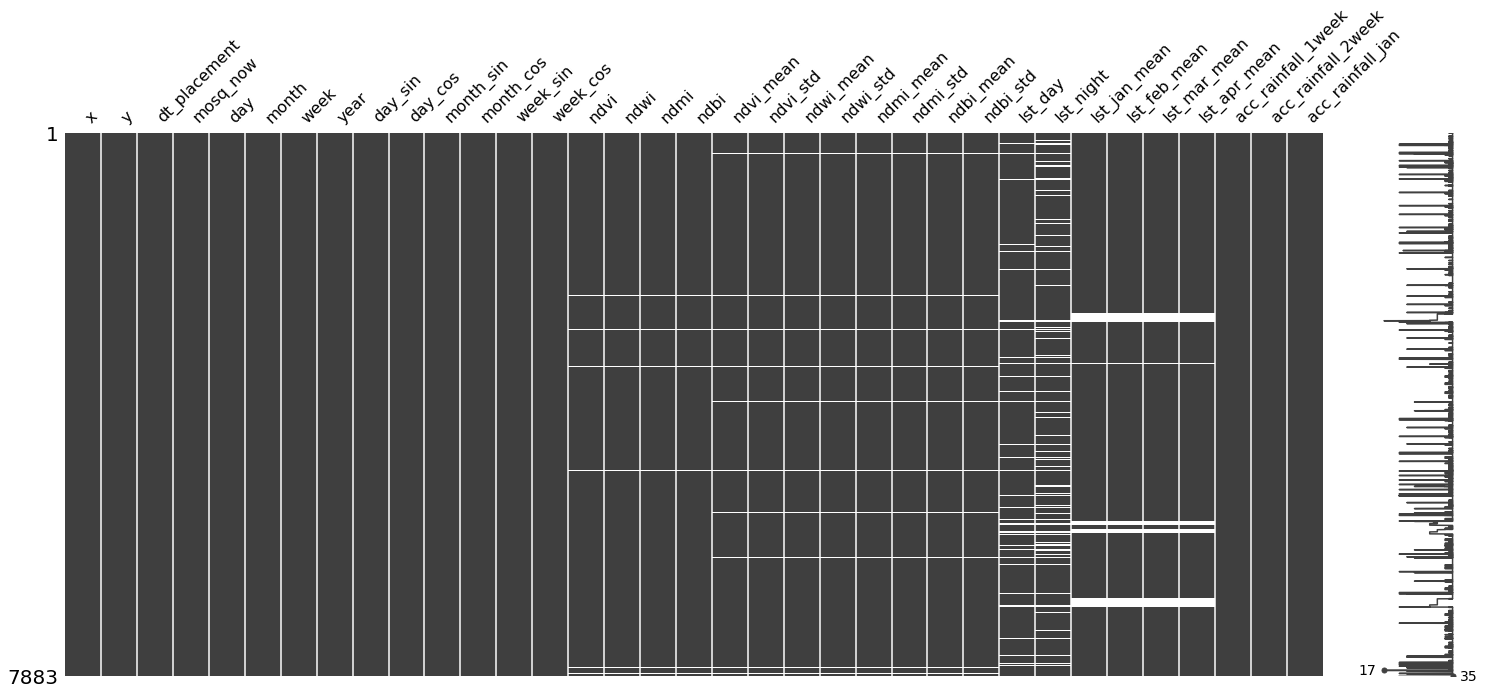

In [23]:
missingno.matrix(mosquito_data_nuts2)

In [24]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [25]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

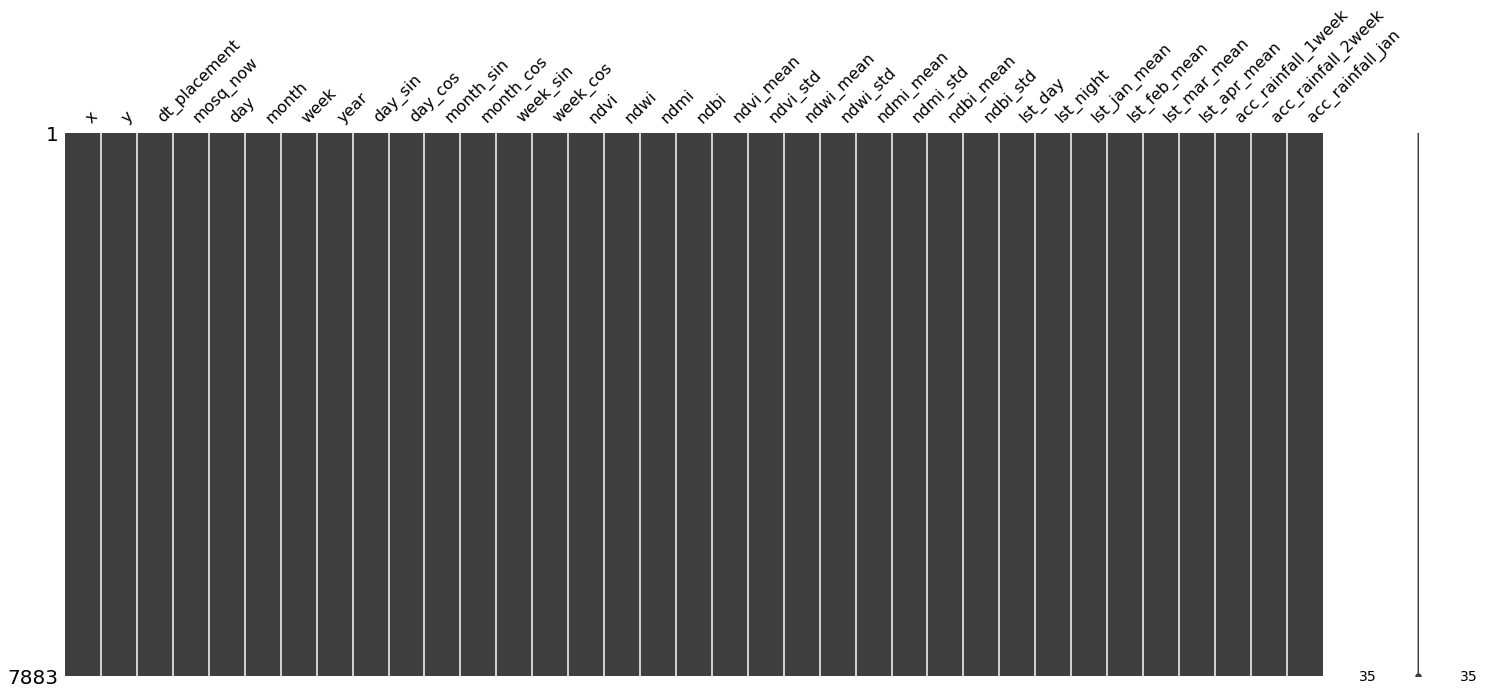

In [26]:
missingno.matrix(mosquito_data_nuts2)

In [27]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [28]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.  85. 755.]


In [29]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 20.37418 | Val Loss: 27.89313 | Train Acc: 2.855| Val Acc: 2.287
Epoch 002: | Train Loss: 18.70076 | Val Loss: 25.30168 | Train Acc: 2.260| Val Acc: 2.144
Epoch 003: | Train Loss: 18.40780 | Val Loss: 24.43396 | Train Acc: 2.212| Val Acc: 2.029
Epoch 004: | Train Loss: 17.87929 | Val Loss: 24.82775 | Train Acc: 2.108| Val Acc: 2.076
Epoch 005: | Train Loss: 17.79331 | Val Loss: 24.33189 | Train Acc: 2.098| Val Acc: 2.021
Epoch 006: | Train Loss: 17.56178 | Val Loss: 24.07761 | Train Acc: 2.036| Val Acc: 2.003
Epoch 007: | Train Loss: 17.18320 | Val Loss: 24.33446 | Train Acc: 2.001| Val Acc: 2.019
Epoch 008: | Train Loss: 17.12101 | Val Loss: 23.99602 | Train Acc: 2.003| Val Acc: 2.026
Epoch 009: | Train Loss: 16.76179 | Val Loss: 23.46590 | Train Acc: 1.969| Val Acc: 1.985
Epoch 010: | Train Loss: 16.65422 | Val Loss: 24.09299 | Train Acc: 1.933| Val Acc: 2.015
Epoch 011: | Train Loss: 16.47414 | Val Loss: 24.34909 | Train Acc: 1.946| Val Acc: 2.030
Epoch 012:

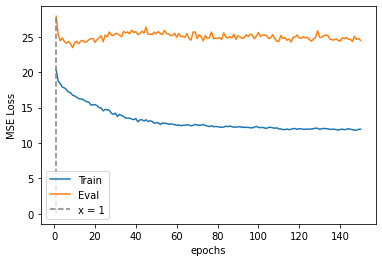

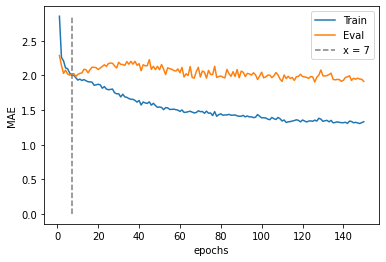

In [30]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [31]:
metrics(train, test, threshold=30)

MAE on train set:  161.01010802787695
min prediction: 1
max prediction: 726

MAE on test set:  152.12764557651087
Error ⩽ 30: 20.27 %
min prediction: 1
max prediction: 636


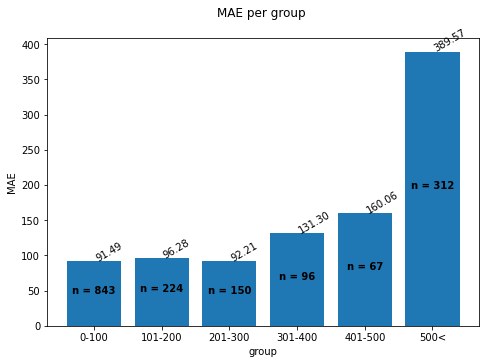

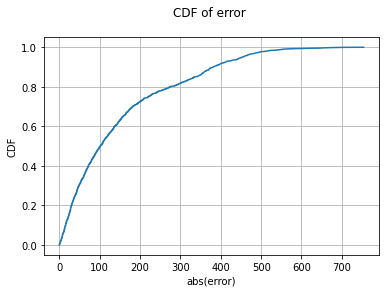

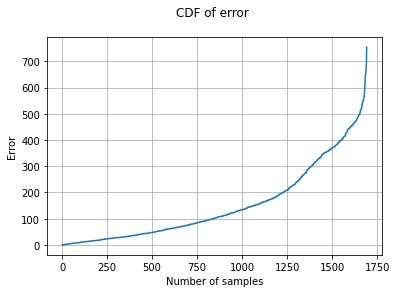

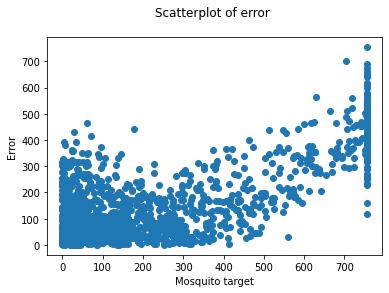

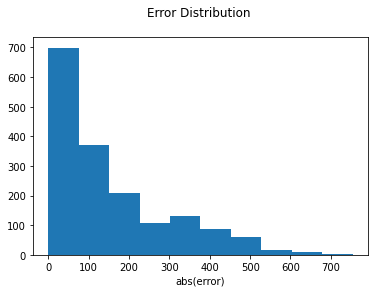

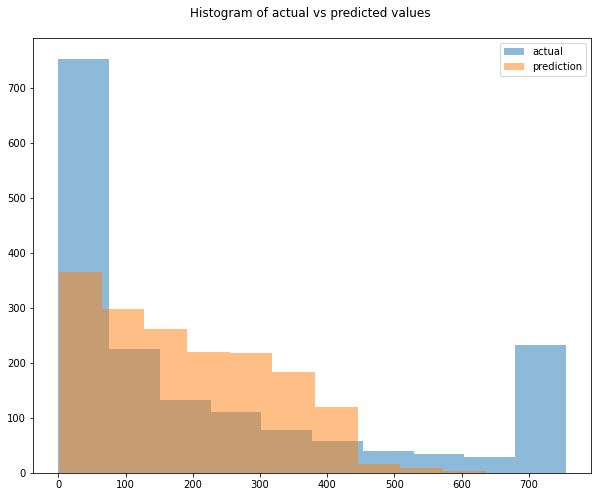

In [32]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 13.86989 | Val Loss: 3.69129 | Train Acc: 1.557| Val Acc: 1.633
Epoch 002: | Train Loss: 13.49806 | Val Loss: 3.98219 | Train Acc: 1.522| Val Acc: 1.633
Epoch 003: | Train Loss: 13.14730 | Val Loss: 5.23343 | Train Acc: 1.481| Val Acc: 2.633
Epoch 004: | Train Loss: 13.18606 | Val Loss: 5.96371 | Train Acc: 1.467| Val Acc: 2.633
Epoch 005: | Train Loss: 13.07419 | Val Loss: 4.40414 | Train Acc: 1.461| Val Acc: 1.633
Epoch 006: | Train Loss: 12.89811 | Val Loss: 5.11629 | Train Acc: 1.445| Val Acc: 2.633
Epoch 007: | Train Loss: 13.15806 | Val Loss: 4.58125 | Train Acc: 1.498| Val Acc: 2.633
Epoch 008: | Train Loss: 12.93251 | Val Loss: 3.05669 | Train Acc: 1.466| Val Acc: 1.633
Epoch 009: | Train Loss: 12.91012 | Val Loss: 3.98498 | Train Acc: 1.457| Val Acc: 1.633
Epoch 010: | Train Loss: 13.03333 | Val Loss: 2.27541 | Train Acc: 1.485| Val Acc: 1.633
Epoch 011: | Train Loss: 12.97965 | Val Loss: 2.37626 | Train Acc: 1.463| Val Acc: 1.633
Epoch 012: | Train Lo

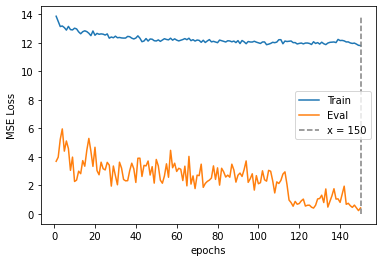

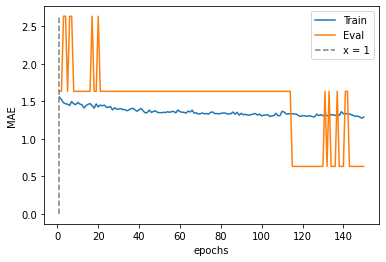

In [33]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [34]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [35]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [36]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [37]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [38]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [39]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

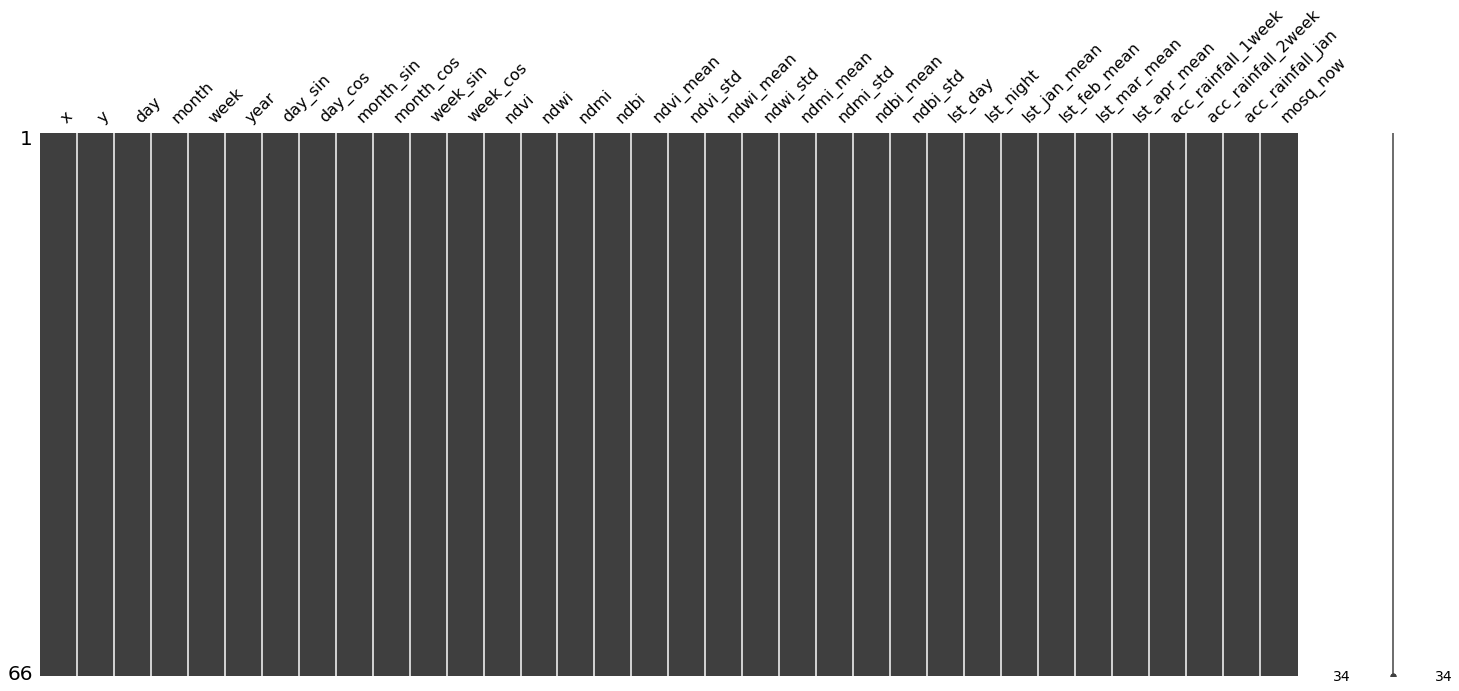

In [40]:
missingno.matrix(dataset_mamoth)

In [41]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [42]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [43]:
predictions = give_predictions(model, dataset_mamoth)

In [44]:
mosqutio_predictions['mosq_pred'] = predictions

In [45]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,23.656970,37.992200,2023-07-16,93
1,23.826420,38.008060,2023-07-16,51
2,23.730310,37.933570,2023-07-16,90
3,23.713410,38.047210,2023-07-16,78
4,23.340090,37.695030,2023-07-16,113
...,...,...,...,...
61,23.776280,38.014770,2023-07-16,67
62,23.688620,38.106703,2023-07-16,109
63,23.809410,38.022260,2023-07-16,62
64,23.630840,38.009420,2023-07-16,86


In [46]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_{YEAR}-{MONTH}-{PERIOD}.csv', index = False)